# Visualization gallery

Render rasters without leaving Python:

- **`to_image`** — a colour-mapped `PIL.Image` (renders inline, no matplotlib figure).
- **`plot`** — a full matplotlib figure via cleopatra (colorbars, basemaps, RGB).
- **`plot_histogram`** — the value distribution of a band.

These need the `[viz]` extra. The setup cell forces matplotlib's headless **Agg** backend so
nothing tries to open a window.

## Setup

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-t2-'))
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.dataset import Dataset

dem = Dataset.read_file(DATA / 'dem' / 'DEM5km_Rhine_burned_acc.tif')
dem.shape

(1, 125, 93)

## Quick colour-mapped image — `to_image`

Returns a `PIL.Image`, which Jupyter renders inline.

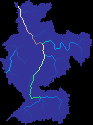

In [3]:
image = dem.to_image(band=0, cmap='terrain')
image

## A full figure — `plot`

`plot` returns a cleopatra `ArrayGlyph`. We save its figure to PNG and display that, so the
render shows up regardless of the (headless) backend.

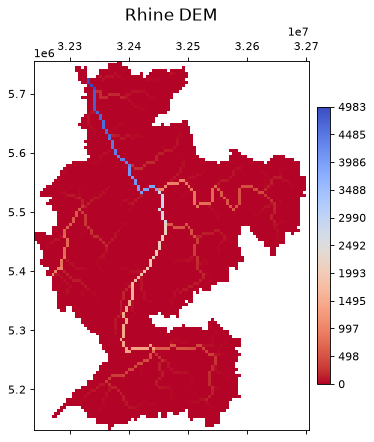

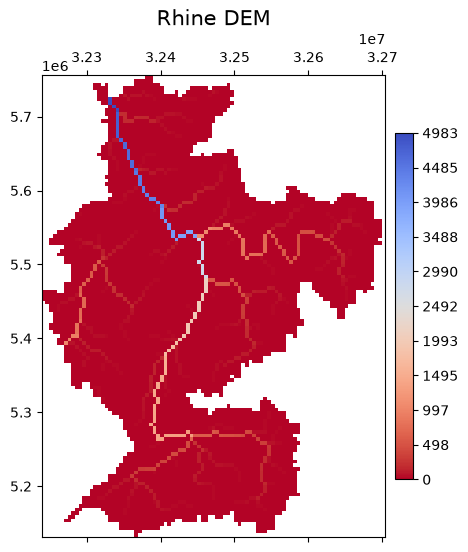

In [4]:
from IPython.display import Image as IPyImage

glyph = dem.plot(band=0, title='Rhine DEM')
png = WORK / 'dem_plot.png'
glyph.fig.savefig(png, dpi=80, bbox_inches='tight')
IPyImage(png)

## Value distribution — `plot_histogram`

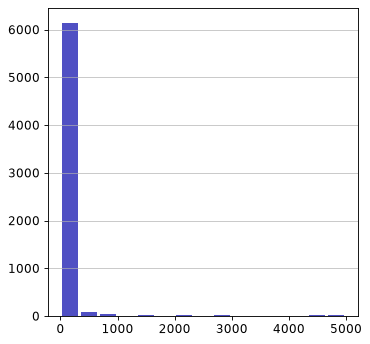

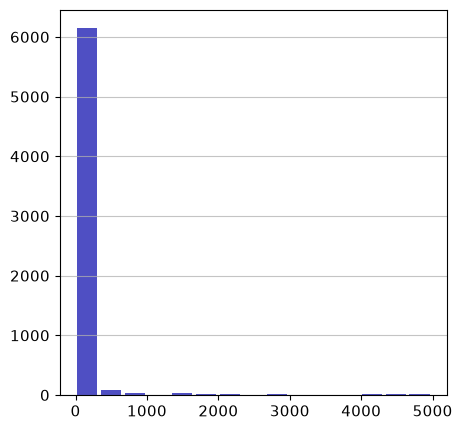

In [5]:
result = dem.plot_histogram()
fig = result[0] if isinstance(result, tuple) else result
hist_png = WORK / 'dem_hist.png'
fig.savefig(hist_png, dpi=80, bbox_inches='tight')
IPyImage(hist_png)

## Notes

- `to_image` is the lightest path (no figure); `plot` gives colorbars, RGB composites
  (`rgb=[...]`), percentile stretches, and basemaps (`basemap=True`).
- `plot(overview=True, overview_index=...)` renders a coarse [overview](overviews.ipynb) — fast
  for huge rasters.
- See also: [Terrain analysis](terrain-analysis.ipynb).